<a href="https://colab.research.google.com/github/agduyaguit/psba-asd2-assignment002/blob/master/ASD2_A2_152QCQTQ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
from pathlib import Path
import urllib.request
import zipfile
import gc
import hashlib
import importlib.metadata as importlib_metadata
import json
import os
import platform
import random
import time


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import xgboost as xgb

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support
)

from xgboost import XGBClassifier

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("GPU devices: ", tf.config.list_physical_devices("GPU"))
print("Tensorflow version: ", tf.__version__)
print("Python version: ", platform.python_version())

GPU devices:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Tensorflow version:  2.20.0
Python version:  3.12.13


In [36]:
PROJECT_ROOT = Path("content/ADS2_A2_WearableHAR")

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
FIGURE_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR = PROJECT_ROOT / "results"

for folder in [RAW_DIR, PROCESSED_DIR, MODEL_DIR, FIGURE_DIR, RESULTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)
print("Directories created! Project Folder: ", PROJECT_ROOT)


DATASET_URL = (
    "https://archive.ics.uci.edu/static/public/256/daily%2Band%2Bsports%2Bactivities.zip"
)

ZIP_PATH = RAW_DIR / "daily_sports_activities.zip"

if not ZIP_PATH.exists():
    urllib.request.urlretrieve(DATASET_URL, str(ZIP_PATH))
    print("Dataset downloaded.")
else:
    print("ZIP file already exists.")

print("ZIP location:", ZIP_PATH)

EXTRACT_DIR = RAW_DIR / "daily_sports_activities"

if not EXTRACT_DIR.exists():
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_file:
        zip_file.extractall(EXTRACT_DIR)

    print("Dataset extracted.")
else:
    print("Extracted dataset already exists.")

print("Extracted location:", EXTRACT_DIR)


Directories created! Project Folder:  content/ADS2_A2_WearableHAR
ZIP file already exists.
ZIP location: content/ADS2_A2_WearableHAR/data/raw/daily_sports_activities.zip
Extracted dataset already exists.
Extracted location: content/ADS2_A2_WearableHAR/data/raw/daily_sports_activities


In [37]:
def find_dataset_root(search_root: Path) -> Path:
  if ((search_root / "a01").is_dir()and (search_root / "a19").is_dir()):
    return search_root

  for a01_directory in search_root.rglob("a01"):
    candidate = a01_directory.parent

    if ((candidate / "a01").is_dir() and (candidate / "a19").is_dir()):
      return candidate

  raise FileNotFoundError(
      f"Could not find a folder containing a01 and a19 "
      f"under {search_root}. Check PROJECT_ROOT or move "
      f"the extracted dataset below RAW_DIR."
  )


DATASET_ROOT = find_dataset_root(RAW_DIR)

print("Project root:", PROJECT_ROOT)
print("Dataset root:", DATASET_ROOT)

Project root: content/ADS2_A2_WearableHAR
Dataset root: content/ADS2_A2_WearableHAR/data/raw/daily_sports_activities/data


In [38]:
sensor_files = sorted(EXTRACT_DIR.rglob("s*.txt"))

print("Number of sensor files:", len(sensor_files))
print("First file:", sensor_files[0])

sample = np.loadtxt(sensor_files[0], delimiter=",")

print("Sample shape:", sample.shape)
print("Contains NaN:", np.isnan(sample).any())

Number of sensor files: 9120
First file: content/ADS2_A2_WearableHAR/data/raw/daily_sports_activities/data/a01/p1/s01.txt
Sample shape: (125, 45)
Contains NaN: False


In [39]:
# LABEL AND SENSOR DEFINITIONS

ACTIVITY_NAMES = {
    "a01": "Sitting",
    "a02": "Standing",
    "a03": "Lying on back",
    "a04": "Lying on right side",
    "a05": "Ascending stairs",
    "a06": "Descending stairs",
    "a07": "Standing in a still elevator",
    "a08": "Moving around in an elevator",
    "a09": "Walking in a parking lot",
    "a10": "Treadmill walking, flat",
    "a11": "Treadmill walking, inclined",
    "a12": "Treadmill running",
    "a13": "Stepper exercise",
    "a14": "Cross-trainer exercise",
    "a15": "Exercise bike, horizontal",
    "a16": "Exercise bike, vertical",
    "a17": "Rowing",
    "a18": "Jumping",
    "a19": "Playing basketball",
}

ACTIVITY_TO_ID = {
    activity_code: index
    for index, activity_code in enumerate(ACTIVITY_NAMES)
}

ID_TO_ACTIVITY = {
    activity_id: ACTIVITY_NAMES[activity_code]
    for activity_code, activity_id in ACTIVITY_TO_ID.items()
}

ID_TO_CODE = {
    activity_id: activity_code.upper()
    for activity_code, activity_id in ACTIVITY_TO_ID.items()
}

BODY_LOCATIONS = {
    "Torso": 0,
    "Right arm": 9,
    "Left arm": 18,
    "Right leg": 27,
    "Left leg": 36
}

SENSOR_AXES = [
     "acc_x",
    "acc_y",
    "acc_z",
    "gyro_x",
    "gyro_y",
    "gyro_z",
    "mag_x",
    "mag_y",
    "mag_z",
]

CHANNEL_NAMES = [
    f"{body_location}_{sensor_axis}"
    for body_location in BODY_LOCATIONS
    for sensor_axis in SENSOR_AXES
]

print("Number of activities:", len(ACTIVITY_NAMES))
print("Number of sensor channels:", len(CHANNEL_NAMES))

Number of activities: 19
Number of sensor channels: 45


In [40]:
# CREATE METADATA TABLE
sensor_files = sorted(DATASET_ROOT.glob("a*/p*/s*.txt"))

metadata_rows = []

for filepath in sensor_files:
  activity_code = filepath.parent.parent.name.lower()
  participant = filepath.parent.name.lower()
  segment = filepath.stem.lower()

  if activity_code not in ACTIVITY_TO_ID:
    continue

  metadata_rows.append({
    "filepath": str(filepath),
    "activity_code": activity_code,
    "activity_id": ACTIVITY_TO_ID[activity_code],
    "activity_name": ACTIVITY_NAMES[activity_code],
    "participant": participant,
    "segment": segment
    })

metadata = pd.DataFrame(metadata_rows)
metadata = metadata.sort_values([
  "activity_id",
  "participant",
  "segment"
]).reset_index(drop=True)

display(metadata.head())

print("Metadata shape:", metadata.shape)
print("Activities:", metadata["activity_code"].nunique())
print("Participants:", metadata["participant"].nunique())

assert len(metadata) == 9120, (f"Expected 9120 files, found {len(metadata)}")
assert metadata["activity_code"].nunique() == 19
assert metadata["participant"].nunique() == 8

metadata.to_csv(
    PROCESSED_DIR / "metadata.csv",
    index=False,
)

,filepath,activity_code,activity_id,activity_name,participant,segment
0,content/ADS2_A2_WearableHAR/data/raw/daily_spo...,a01,0,Sitting,p1,s01
1,content/ADS2_A2_WearableHAR/data/raw/daily_spo...,a01,0,Sitting,p1,s02
2,content/ADS2_A2_WearableHAR/data/raw/daily_spo...,a01,0,Sitting,p1,s03
3,content/ADS2_A2_WearableHAR/data/raw/daily_spo...,a01,0,Sitting,p1,s04
4,content/ADS2_A2_WearableHAR/data/raw/daily_spo...,a01,0,Sitting,p1,s05


Metadata shape: (9120, 6)
Activities: 19
Participants: 8


In [41]:
# LOAD SENSOR DATA
ARRAY_CACHE_PATH = PROCESSED_DIR / "daily_sports_arrays.npz"

def load_sensor_sequence(filepath: str) -> np.ndarray:
  sequence = np.loadtxt(filepath, delimiter=",", dtype=np.float32)

  if sequence.shape != (125, 45):
    raise ValueError(f"Unexpected shape {sequence.shape}. Expected (125, 45): {filepath}")

  if not np.isfinite(sequence).all():
    raise ValueError(f"NaN or infinite value found in {filepath}")

  return sequence

if ARRAY_CACHE_PATH.exists():
  cached = np.load(ARRAY_CACHE_PATH, allow_pickle=True)
  X = cached["X"].astype(np.float32)
  y = cached["y"].astype(np.int32)
  subjects = cached["subjects"].astype(str)

  print("Loaded arrays from cache: ", ARRAY_CACHE_PATH)

else:
  X = np.empty((len(metadata), 125, 45), dtype=np.float32)
  y = np.empty(len(metadata), dtype=np.int32)
  subjects = np.empty(len(metadata), dtype="<U3")

  for index, row in enumerate(metadata.itertuples(index=False)):
    X[index] = load_sensor_sequence(row.filepath)
    y[index] = row.activity_id
    subjects[index] = row.participant

    if (index + 1) % 1000 == 0:
      print(f"Loaded {index + 1:,} / {len(metadata):,} files")

np.savez_compressed(ARRAY_CACHE_PATH, X=X, y=y, subjects=subjects)

print(f"Saved arrays to cache!", ARRAY_CACHE_PATH)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Subjects shape:", subjects.shape)
print("NaN count: ", int(np.isnan(X).sum()))
print("Infinite count: ", int(np.isinf(X).sum()))

assert X.shape == (9120, 125, 45)
assert y.shape == (9120,)
assert subjects.shape == (9120,)
assert np.isfinite(X).all()
assert set(np.unique(y)) == set(range(19))

Loaded arrays from cache:  content/ADS2_A2_WearableHAR/data/processed/daily_sports_arrays.npz
Saved arrays to cache! content/ADS2_A2_WearableHAR/data/processed/daily_sports_arrays.npz
X shape: (9120, 125, 45)
y shape: (9120,)
Subjects shape: (9120,)
NaN count:  0
Infinite count:  0


In [42]:
# EXACT DUPLICATE CHECK

sequence_hashes = [hashlib.md5(sequence.tobytes()).hexdigest() for sequence in X]

duplicate_mask = pd.Series(sequence_hashes).duplicated(keep=False)

duplicate_count = int(duplicate_mask.sum())

print("Sequences involved in exact duplicate groups: ", duplicate_count)

if duplicate_count > 0:
  duplicate_report = metadata.loc[duplicate_mask].copy()
  duplicate_report["sequence_hash"] = np.array(sequence_hashes)[duplicate_mask]

  display(duplicate_report.sort_values("sequence_hash").head(20))

Sequences involved in exact duplicate groups:  0


,activity_code,activity_name,count
0,a01,Sitting,480
1,a02,Standing,480
2,a03,Lying on back,480
3,a04,Lying on right side,480
4,a05,Ascending stairs,480
5,a06,Descending stairs,480
6,a07,Standing in a still elevator,480
7,a08,Moving around in an elevator,480
8,a09,Walking in a parking lot,480
9,a10,"Treadmill walking, flat",480


,participant,count
0,p1,1140
1,p2,1140
2,p3,1140
3,p4,1140
4,p5,1140
5,p6,1140
6,p7,1140
7,p8,1140


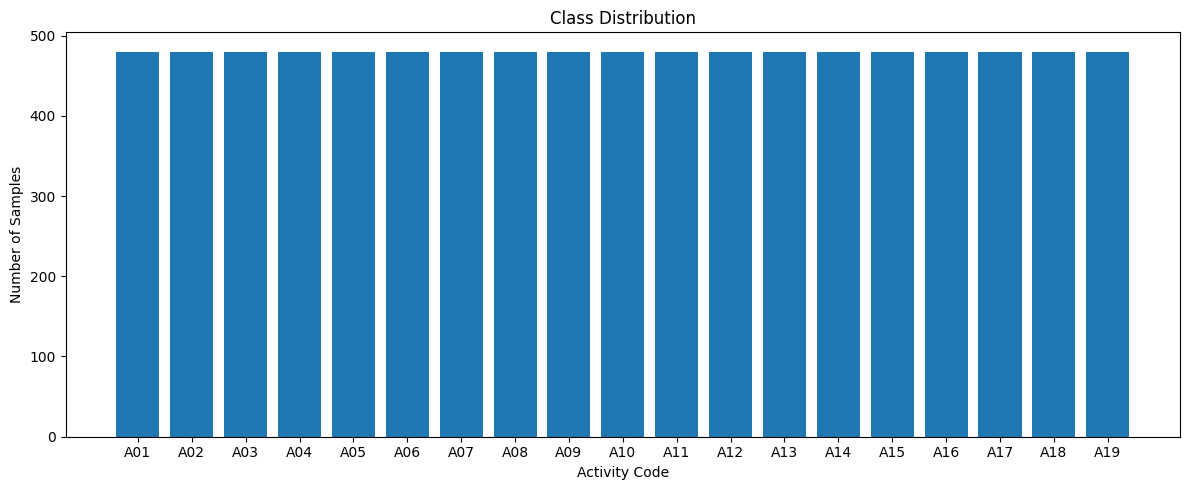

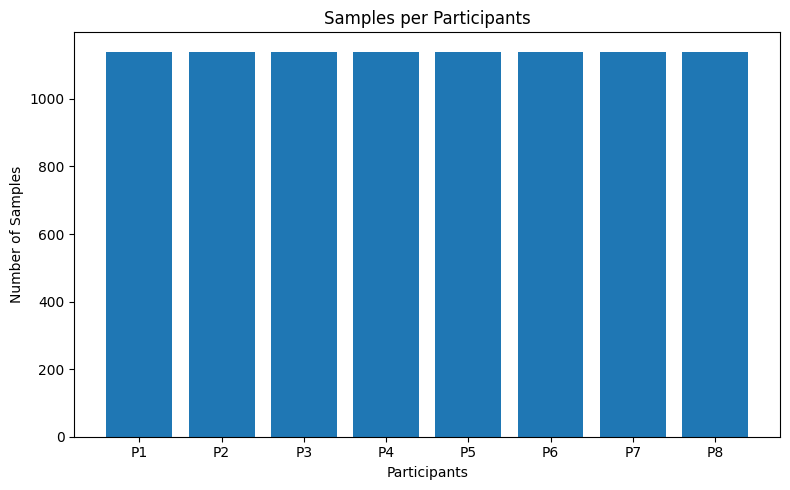

In [43]:
# CLASS and PARTICIPANTS DISTRIBUTION
activity_counts = metadata.groupby(["activity_code", "activity_name"]).size().reset_index(name="count")

participants_counts= metadata.groupby("participant").size().reset_index(name="count")

display(activity_counts)
display(participants_counts)

plt.figure(figsize=(12, 5))
plt.bar(activity_counts["activity_code"].str.upper(), activity_counts["count"])
plt.xlabel("Activity Code")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(participants_counts["participant"].str.upper(), participants_counts["count"])
plt.xlabel("Participants")
plt.ylabel("Number of Samples")
plt.title("Samples per Participants")
plt.tight_layout()
plt.show()


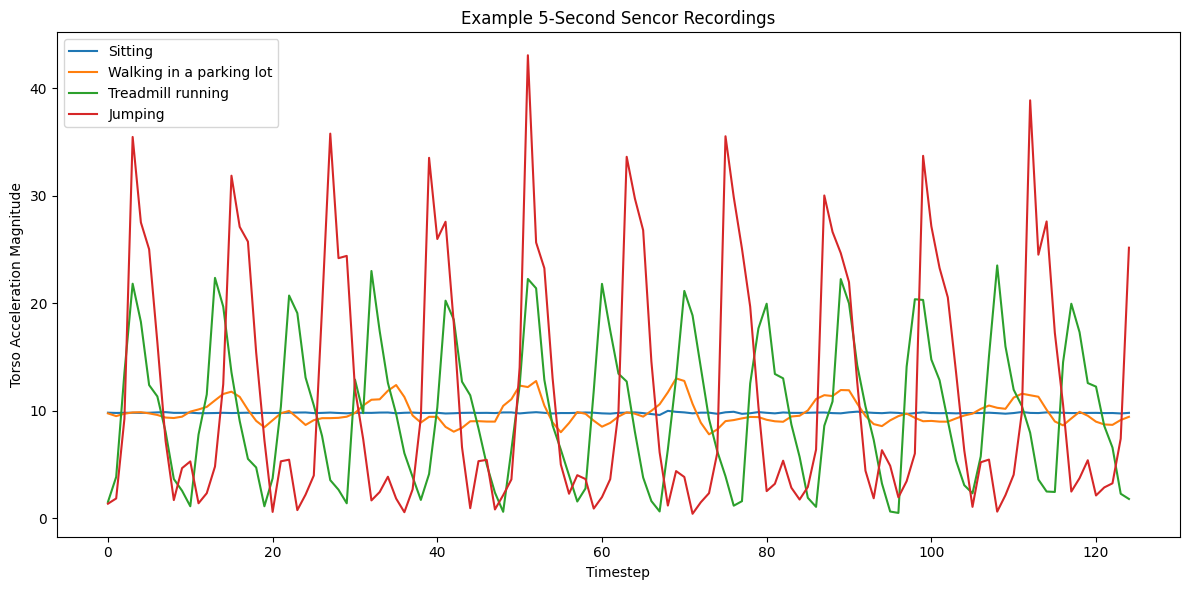

In [44]:
# EXAMPLE SENSOR SIGNALS

def acceleration_magnitude(sequence: np.ndarray, body_start_index: str) -> np.ndarray:
  accelaration = sequence[:,body_start_index:body_start_index + 3]

  return np.sqrt(np.sum(np.square(accelaration), axis=1))

example_codes = ["a01", "a09", "a12", "a18"]

plt.figure(figsize=(12, 6))

for activity_code in example_codes:
  example_index = metadata.index[metadata["activity_code"].eq(activity_code)][0]
  torso_acceleration = acceleration_magnitude(X[example_index], BODY_LOCATIONS["Torso"])

  plt.plot(np.arange(125), torso_acceleration, label=ACTIVITY_NAMES[activity_code])

plt.xlabel("Timestep")
plt.ylabel("Torso Acceleration Magnitude")
plt.title("Example 5-Second Sencor Recordings")
plt.legend()
plt.tight_layout()
plt.show()


In [45]:
# SENSOR SUMMARY

sensor_summary = pd.DataFrame({
    "channel": CHANNEL_NAMES,
    "mean": np.mean(X, axis=(0, 1)),
    "standard_deviation": np.std(X, axis=(0, 1)),
    "minimum": np.min(X, axis=(0, 1)),
    "maximum": np.max(X, axis=(0, 1)),
})

display(sensor_summary.head())

sensor_summary.to_csv(RESULTS_DIR / "sensor_summary.csv", index=False)


,channel,mean,standard_deviation,minimum,maximum
0,Torso_acc_x,7.765744,5.635097,-99.714996,93.694000
1,Torso_acc_y,-0.810956,2.621704,-49.941002,41.013000
2,Torso_acc_z,2.768911,3.537025,-62.664001,120.529999
3,Torso_gyro_x,-0.002796,0.793810,-27.851000,27.671000
4,Torso_gyro_y,0.013695,0.690814,-23.598000,14.379000


In [46]:
# SUBJECT - BASED SPLIT

TRAIN_SUBJECT = ["p1", "p2", "p3", "p4", "p5"]
VAL_SUBJECT = ["p6"]
TEST_SUBJECT = ["p7", "p8", "p9"]

train_mask = np.isin(subjects, TRAIN_SUBJECT)
val_mask = np.isin(subjects, VAL_SUBJECT)
test_mask = np.isin(subjects, TEST_SUBJECT)

assert not np.any(train_mask & val_mask)
assert not np.any(train_mask & test_mask)
assert not np.any(val_mask & test_mask)
assert np.all(train_mask | val_mask | test_mask)

print("Train mask shape:", train_mask.shape)
print("Val mask shape:", val_mask.shape)
print("Test mask shape:", test_mask.shape)

X_train = X[train_mask]
y_train = y[train_mask]

X_val = X[val_mask]
y_val = y[val_mask]

X_test = X[test_mask]
y_test = y[test_mask]

subjects_train = subjects[train_mask]
subjects_val = subjects[val_mask]
subjects_test = subjects[test_mask]

assert X_train.shape == (5700, 125, 45)
assert X_val.shape == (1140, 125, 45)
assert X_test.shape == (2280, 125, 45)

split_labels = np.full(len(metadata), "", dtype="<U10")
split_labels[train_mask] = "train"
split_labels[val_mask] = "validation"
split_labels[test_mask] = "test"

split_manifest = metadata.copy()
split_manifest["split"] = split_labels

split_manifest.to_csv(RESULTS_DIR / "split_manifest.csv", index=False)


Train mask shape: (9120,)
Val mask shape: (9120,)
Test mask shape: (9120,)


In [47]:
# SPLIT CLASS DISTRIBUTION
def create_class_distribution(labels: np.ndarray, split_name: str) -> pd.DataFrame:
  counts = pd.Series(labels).value_counts().sort_index()

  return pd.DataFrame({
      "split": split_name,
      "activity_id": counts.index,
      "activity_code": [ID_TO_CODE[index] for index in counts.index],
      "activity_name": [ID_TO_ACTIVITY[index] for index in counts.index],
      "count": counts.values
  })

class_distribution = pd.concat([
    create_class_distribution(y_train, "train"),
    create_class_distribution(y_val, "validation"),
    create_class_distribution(y_test, "Test"),
])

display(class_distribution)

distribution_pivot = class_distribution.pivot(index=["activity_code", "activity_name"], columns="split", values="count")

display(distribution_pivot)

assert y_train.shape[0] == 19 * 5 * 60
assert y_val.shape[0] == 19 * 1 * 60
assert y_test.shape[0] == 19 * 2 * 60

,split,activity_id,activity_code,activity_name,count
0,train,0,A01,Sitting,300
1,train,1,A02,Standing,300
2,train,2,A03,Lying on back,300
3,train,3,A04,Lying on right side,300
4,train,4,A05,Ascending stairs,300
5,train,5,A06,Descending stairs,300
6,train,6,A07,Standing in a still elevator,300
7,train,7,A08,Moving around in an elevator,300
8,train,8,A09,Walking in a parking lot,300
9,train,9,A10,"Treadmill walking, flat",300


,split,Test,train,validation
activity_code,activity_name,,,
A01,Sitting,120,300,60
A02,Standing,120,300,60
A03,Lying on back,120,300,60
A04,Lying on right side,120,300,60
A05,Ascending stairs,120,300,60
A06,Descending stairs,120,300,60
A07,Standing in a still elevator,120,300,60
A08,Moving around in an elevator,120,300,60
A09,Walking in a parking lot,120,300,60


In [48]:
# NORMALISATION

train_mean = np.mean(X_train, axis=(0, 1), keepdims=True).astype(np.float32)
train_std = np.std(X_train, axis=(0, 1), keepdims=True).astype(np.float32)

train_std = np.where(train_std < 1e-8, 1.0, train_std)

X_train_scaled = ((X_train - train_mean) / train_std).astype(np.float32)
X_val_scaled = ((X_val - train_mean) / train_std).astype(np.float32)
X_test_scaled = ((X_test - train_mean) / train_std).astype(np.float32)

print("Train mean shape:", train_mean.shape)
print("Train std shape:", train_std.shape)

print("First Five(5) scaled training means: ")
print(np.mean(X_train_scaled, axis=(0, 1)[:5]))
print("First Five(5) scaled training standard deviations: ")
print(np.std(X_train_scaled, axis=(0, 1)[:5]))

np.savez_compressed(PROCESSED_DIR / "normalisation_statistics_npz", train_mean=train_mean, train_std=train_std)

Train mean shape: (1, 1, 45)
Train std shape: (1, 1, 45)
First Five(5) scaled training means: 
[-4.51507049e-06 -2.31406975e-05  3.40083716e-06 -1.01917985e-08
 -8.10616498e-08  9.52909076e-08  6.41349616e-05 -5.79702885e-07
  1.82271287e-05 -2.05749584e-05 -6.92367212e-06  8.39507084e-06
  9.46183789e-08  1.05178898e-07 -9.45991374e-08  3.67813004e-06
 -1.81672058e-05  1.12590669e-05 -3.45402853e-08 -9.25538734e-06
 -1.63721415e-05  2.96086597e-07 -3.41286921e-07 -2.27415775e-08
 -1.31458573e-05  9.58593864e-06 -1.57452869e-05 -2.58845944e-06
  3.39913458e-05  3.69038571e-05 -2.93186257e-08 -6.17480055e-07
 -3.84566654e-08  4.09983695e-05 -6.34755270e-06  9.94540187e-06
 -3.81278478e-05  9.88322063e-06  1.37776874e-06 -2.50278021e-08
 -8.41294650e-07  3.69158961e-08  3.35932818e-05 -4.83882286e-06
 -7.21254082e-07]
First Five(5) scaled training standard deviations: 
[0.9999456  1.0000505  1.0000151  1.0000364  0.99998605 1.0000217
 0.9998422  0.99997693 1.000015   1.0000046  0.9999832

In [49]:
# TF.DATA PIPELINE
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

def make_tf_dataset(features: np.ndarray, labels: np.ndarray, training: bool) -> tf.data.Dataset:
  dataset = tf.data.Dataset.from_tensor_slices((features, labels))

  dataset = dataset.cache()

  if training:
    dataset = dataset.shuffle(buffer_size=len(features), seed=SEED, reshuffle_each_iteration=True)

  dataset = dataset.batch(BATCH_SIZE)
  dataset = dataset.prefetch(buffer_size=AUTOTUNE)

  return dataset

train_ds = make_tf_dataset(X_train_scaled, y_train, training=True)
val_ds = make_tf_dataset(X_val_scaled, y_val, training=False)
test_ds = make_tf_dataset(X_test_scaled, y_test, training=False)

for batch_features, batch_labels in train_ds.take(1):
  print("Feature Batch: ", batch_features.shape)
  print("Label Batch: ", batch_labels.shape)


Feature Batch:  (64, 125, 45)
Label Batch:  (64,)


In [50]:
# BASELINE FEATURE ENGINEERING

FEATURE_GROUP_NAMES = [
  "mean",
  "standard_deviation",
  "minimum",
  "maximum",
  "median",
  "range",
  "root_mean_square",
  "mean_energy"
]

def extract_statistical_features(sequences: np.ndarray) -> np.ndarray:
  feature_groups = [
      np.mean(sequences, axis=1),
      np.std(sequences, axis=1),
      np.min(sequences, axis=1),
      np.max(sequences, axis=1),
      np.median(sequences, axis=1),
      np.ptp(sequences, axis=1),
      np.sqrt(np.mean(np.square(sequences), axis=1)),
      np.mean(np.square(sequences), axis=1)
  ]

  return np.concatenate(feature_groups, axis=1).astype(np.float32)

X_train_features = extract_statistical_features(X_train)
X_val_features = extract_statistical_features(X_val)
X_test_features = extract_statistical_features(X_test)

baseline_feature_names = [
    f"{statistic}_{channel}"
    for statistic in FEATURE_GROUP_NAMES
    for channel in CHANNEL_NAMES
]

print("Train feature shape: ", X_train_features.shape)
print("Val feature shape: ", X_val_features.shape)
print("Test feature shape: ", X_test_features.shape)
print("Number of feature names: ", len(baseline_feature_names))

assert X_train_features.shape[1] == 45 * len(FEATURE_GROUP_NAMES)

Train feature shape:  (5700, 360)
Val feature shape:  (1140, 360)
Test feature shape:  (2280, 360)
Number of feature names:  360


In [51]:
### XGBOOST BASELINE

xgb_model = XGBClassifier(
  objective="multi:softprob",
  num_class=19,
  n_estimators=350,
  learning_rate=0.05,
  max_depth=6,
  min_child_weight=1,
  subsample=0.90,
  colsample_bytree=0.90,
  reg_alpha=0.0,
  reg_lambda=1.0,
  tree_method="hist",
  eval_metric="mlogloss",
  random_state=SEED,
  n_jobs=-1,
)

xgb_training_start = time.perf_counter()

xgb_model.fit(X_train_features, y_train, eval_set=[(X_val_features, y_val)], verbose=False)

xgb_training_seconds = time.perf_counter() - xgb_training_start

xgb_val_probabilities = xgb_model.predict_proba(X_val_features)
xgb_val_predictions = np.argmax(xgb_val_probabilities, axis=1)
xgb_val_accuracy = accuracy_score(y_val, xgb_val_predictions)
xgb_val_macro_f1 = f1_score(y_val, xgb_val_predictions, average="macro")

XGB_MODEL_PATH = MODEL_DIR / "xgboost_baseline.json"

xgb_model.save_model(XGB_MODEL_PATH)

print("XGBoost validation accuracy: ", round(xgb_val_accuracy, 4))
print("XGBoost validation macro F1 score: ", round(xgb_val_macro_f1, 4))
print("XGBoost training time: ", round(xgb_training_seconds, 2))

XGBoost validation accuracy:  0.8904
XGBoost validation macro F1 score:  0.8833
XGBoost training time:  74.18


In [52]:
### CNN and BILSTM BUILDERS

NUMBER_OF_CLASSES = 19
INPUT_SHAPE = (125, 45)
L2_STRENGTH = 1e-4

def build_cnn_model(filters: int = 64, kernel_size: int = 5, dropout_rate: float = 0.30,learning_rate: float = 1e-3) -> tf.keras.Model:
  inputs = tf.keras.Input(shape=INPUT_SHAPE, name="sensor_sequence")

  x = tf.keras.layers.Conv1D(
      filters=filters,
      kernel_size=kernel_size,
      padding="same",
      kernel_regularizer=(tf.keras.regularizers.l2(L2_STRENGTH)),
      name="conv_block_1",
    )(inputs)

  x = tf.keras.layers.BatchNormalization()(x)
  x = tf.keras.layers.Activation("relu")(x)
  x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)

  x = tf.keras.layers.Conv1D(
      filters=filters * 2,
      kernel_size=kernel_size,
      padding="same",
      kernel_regularizer=(tf.keras.regularizers.l2(L2_STRENGTH)),
      name="conv_block_2",
  )(x)

  x = tf.keras.layers.BatchNormalization()(x)
  x = tf.keras.layers.Activation("relu")(x)
  x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)

  x = tf.keras.layers.Conv1D(
      filters=filters * 4,
      kernel_size=3,
      padding="same",
      kernel_regularizer=(tf.keras.regularizers.l2(L2_STRENGTH)),
      name="conv_block_3",
  )(x)

  x = tf.keras.layers.BatchNormalization()(x)
  x = tf.keras.layers.Activation("relu")(x)
  x = (tf.keras.layers.GlobalAveragePooling1D())(x)
  x = tf.keras.layers.Dropout(dropout_rate)(x)
  x = tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=(tf.keras.regularizers.l2(L2_STRENGTH)),
  )(x)

  x = tf.keras.layers.Dropout(dropout_rate)(x)

  outputs = tf.keras.layers.Dense(
      NUMBER_OF_CLASSES,
      activation="softmax",
      name="activity_probabilities",
  )(x)

  model = tf.keras.Model(
      inputs=inputs,
      outputs=outputs,
      name=(
        f"cnn_f{filters}"
        f"_k{kernel_size}"
      ),
  )

  model.compile(
      optimizer=(
        tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        )
      ),
      loss=(
        tf.keras.losses.SparseCategoricalCrossentropy()
      ),
      metrics=[
        tf.keras.metrics
        .SparseCategoricalAccuracy(
            name="accuracy"
        )
      ],
  )
  return model


def build_bilstm_model(lstm_units: int = 64,dropout_rate: float = 0.30,learning_rate: float = 1e-3) -> tf.keras.Model:
    inputs = tf.keras.Input(
      shape=INPUT_SHAPE,
      name="sensor_sequence"
    )
    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(
          units=lstm_units,
          return_sequences=True,
        ),
        name="bidirectional_lstm"
    )(inputs)

    x = tf.keras.layers.LayerNormalization()(x)
    x = (
        tf.keras.layers
        .GlobalAveragePooling1D()
    )(x)
    x = tf.keras.layers.Dropout(
        dropout_rate
    )(x)
    x = tf.keras.layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=(tf.keras.regularizers.l2(L2_STRENGTH))
    )(x)

    x = tf.keras.layers.Dropout(
        dropout_rate
    )(x)

    outputs = tf.keras.layers.Dense(
        NUMBER_OF_CLASSES,
        activation="softmax",
        name="activity_probabilities",
    )(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name=(
            f"bilstm_u{lstm_units}"
            f"_d{dropout_rate}"
        ),
    )

    model.compile(
      optimizer=(
          tf.keras.optimizers.Adam(
              learning_rate=learning_rate
          )
        ),
        loss=(
          tf.keras.losses
          .SparseCategoricalCrossentropy()
        ),
        metrics=[
          tf.keras.metrics
          .SparseCategoricalAccuracy(
              name="accuracy"
          )
        ]
    )

    return model

In [53]:
### MODEL SUMMARIES AND DIAGRAMS

example_cnn = build_cnn_model()
example_bilstm = build_bilstm_model()


print("\nCNN summary")
example_cnn.summary()


print("\nBiLSTM summary")
example_bilstm.summary()


try:

    tf.keras.utils.plot_model(
        example_cnn,
        to_file=str(
            FIGURE_DIR
            / "cnn_architecture.png"
        ),
        show_shapes=True,
        show_layer_names=True,
        expand_nested=True,
        dpi=120,
    )

    tf.keras.utils.plot_model(
        example_bilstm,
        to_file=str(
            FIGURE_DIR
            / "bilstm_architecture.png"
        ),
        show_shapes=True,
        show_layer_names=True,
        expand_nested=True,
        dpi=120,
    )

except Exception as error:

    print(
        "Model diagram generation skipped:",
        error,
    )


del example_cnn
del example_bilstm

tf.keras.backend.clear_session()
gc.collect()


CNN summary


Model: "cnn_f64_k5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sensor_sequence (InputLayer)    │ (None, 125, 45)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block_1 (Conv1D)           │ (None, 125, 64)        │        14,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 125, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 125, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 62, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block_2 (Conv1D)           │ (None, 62, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 62, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 62, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 31, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block_3 (Conv1D)           │ (None, 31, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 31, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 31, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activity_probabilities (Dense)  │ (None, 19)             │         1,235 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,587 (678.07 KB)

 Trainable params: 172,691 (674.57 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sensor_sequence (InputLayer)    │ (None, 125, 45)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_lstm              │ (None, 125, 128)       │        56,320 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 125, 128)       │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activity_probabilities (Dense)  │ (None, 19)             │         1,235 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,067 (258.07 KB)

 Trainable params: 66,067 (258.07 KB)

 Non-trainable params: 0 (0.00 B)

0

In [54]:
# CALLBACKS AND TRAINING FUNCTION

MAX_EPOCHS = 10


def create_callbacks(
    experiment_name: str,
):

    checkpoint_path = (
        MODEL_DIR
        / f"{experiment_name}_checkpoint.keras"
    )

    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=6,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_loss",
            save_best_only=True,
            verbose=0,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1,
        ),
    ]


def train_keras_experiment(
    model: tf.keras.Model,
    experiment_name: str,
):

    training_start = (
        time.perf_counter()
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=MAX_EPOCHS,
        callbacks=create_callbacks(
            experiment_name
        ),
        verbose=2,
    )

    training_seconds = (
        time.perf_counter()
        - training_start
    )

    val_probabilities = model.predict(
        X_val_scaled,
        batch_size=BATCH_SIZE,
        verbose=0,
    )

    val_predictions = np.argmax(
        val_probabilities,
        axis=1,
    )

    val_accuracy = accuracy_score(
        y_val,
        val_predictions,
    )

    val_macro_f1 = f1_score(
        y_val,
        val_predictions,
        average="macro",
    )

    model_path = (
        MODEL_DIR
        / f"{experiment_name}.keras"
    )

    model.save(model_path)

    record = {
        "experiment": experiment_name,
        "validation_accuracy": val_accuracy,
        "validation_macro_f1": val_macro_f1,
        "epochs_run": len(
            history.history["loss"]
        ),
        "training_seconds": training_seconds,
        "parameter_count": model.count_params(),
        "model_path": str(model_path),
    }

    return record, history.history

In [55]:
# CNN HYPERPARAMETER EXPERIMENT

cnn_configurations = [
    {
        "filters": 32,
        "kernel_size": 3,
    },
    {
        "filters": 32,
        "kernel_size": 5,
    },
    {
        "filters": 64,
        "kernel_size": 3,
    },
    {
        "filters": 64,
        "kernel_size": 5,
    },
]


cnn_records = []
cnn_histories = {}


for configuration in cnn_configurations:

    tf.keras.backend.clear_session()

    experiment_name = (
        f"cnn_filters_"
        f"{configuration['filters']}"
        f"_kernel_"
        f"{configuration['kernel_size']}"
    )

    print("\n" + "=" * 80)
    print("Training:", experiment_name)
    print("=" * 80)

    model = build_cnn_model(
        filters=configuration[
            "filters"
        ],
        kernel_size=configuration[
            "kernel_size"
        ],
        dropout_rate=0.30,
    )

    record, history = (
        train_keras_experiment(
            model=model,
            experiment_name=experiment_name,
        )
    )

    record.update(configuration)

    cnn_records.append(record)

    cnn_histories[
        experiment_name
    ] = history

    del model
    gc.collect()


cnn_results = (
    pd.DataFrame(cnn_records)
    .sort_values(
        [
            "validation_macro_f1",
            "validation_accuracy",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)


display(cnn_results)


cnn_results.to_csv(
    RESULTS_DIR
    / "cnn_hyperparameter_results.csv",
    index=False,
)


Training: cnn_filters_32_kernel_3
Epoch 1/10
90/90 - 5s - 57ms/step - accuracy: 0.6267 - loss: 1.3889 - val_accuracy: 0.7246 - val_loss: 1.1381 - learning_rate: 0.0010
Epoch 2/10
90/90 - 1s - 16ms/step - accuracy: 0.9104 - loss: 0.3500 - val_accuracy: 0.8149 - val_loss: 0.6298 - learning_rate: 0.0010
Epoch 3/10
90/90 - 1s - 11ms/step - accuracy: 0.9577 - loss: 0.1815 - val_accuracy: 0.8211 - val_loss: 0.6684 - learning_rate: 0.0010
Epoch 4/10
90/90 - 1s - 11ms/step - accuracy: 0.9682 - loss: 0.1382 - val_accuracy: 0.8325 - val_loss: 0.6695 - learning_rate: 0.0010
Epoch 5/10
90/90 - 1s - 12ms/step - accuracy: 0.9765 - loss: 0.1124 - val_accuracy: 0.8588 - val_loss: 0.5421 - learning_rate: 0.0010
Epoch 6/10
90/90 - 1s - 11ms/step - accuracy: 0.9814 - loss: 0.0953 - val_accuracy: 0.8614 - val_loss: 0.4643 - learning_rate: 0.0010
Epoch 7/10
90/90 - 1s - 11ms/step - accuracy: 0.9816 - loss: 0.0962 - val_accuracy: 0.8553 - val_loss: 0.5593 - learning_rate: 0.0010
Epoch 8/10
90/90 - 1s - 11m

,experiment,validation_accuracy,validation_macro_f1,epochs_run,training_seconds,parameter_count,model_path,filters,kernel_size
0,cnn_filters_32_kernel_5,0.950877,0.950113,10,15.615401,52627,content/ADS2_A2_WearableHAR/models/cnn_filters...,32,5
1,cnn_filters_64_kernel_5,0.946491,0.945774,8,45.259225,173587,content/ADS2_A2_WearableHAR/models/cnn_filters...,64,5
2,cnn_filters_64_kernel_3,0.924561,0.921559,10,15.422019,151443,content/ADS2_A2_WearableHAR/models/cnn_filters...,64,3
3,cnn_filters_32_kernel_3,0.861404,0.846707,10,14.714270,45651,content/ADS2_A2_WearableHAR/models/cnn_filters...,32,3


In [56]:
# BILSTM HYPERPARAMETER EXPERIMENT

bilstm_configurations = [
    {
        "lstm_units": 32,
        "dropout_rate": 0.20,
    },
    {
        "lstm_units": 32,
        "dropout_rate": 0.40,
    },
    {
        "lstm_units": 64,
        "dropout_rate": 0.20,
    },
    {
        "lstm_units": 64,
        "dropout_rate": 0.40,
    },
]


bilstm_records = []
bilstm_histories = {}


for configuration in bilstm_configurations:

    tf.keras.backend.clear_session()

    dropout_text = str(
        configuration["dropout_rate"]
    ).replace(
        ".",
        "_",
    )

    experiment_name = (
        f"bilstm_units_"
        f"{configuration['lstm_units']}"
        f"_dropout_{dropout_text}"
    )

    print("\n" + "=" * 80)
    print("Training:", experiment_name)
    print("=" * 80)

    model = build_bilstm_model(
        lstm_units=configuration[
            "lstm_units"
        ],
        dropout_rate=configuration[
            "dropout_rate"
        ],
    )

    record, history = (
        train_keras_experiment(
            model=model,
            experiment_name=experiment_name,
        )
    )

    record.update(configuration)

    bilstm_records.append(record)

    bilstm_histories[
        experiment_name
    ] = history

    del model
    gc.collect()


bilstm_results = (
    pd.DataFrame(bilstm_records)
    .sort_values(
        [
            "validation_macro_f1",
            "validation_accuracy",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)


display(bilstm_results)


bilstm_results.to_csv(
    RESULTS_DIR
    / "bilstm_hyperparameter_results.csv",
    index=False,
)


Training: bilstm_units_32_dropout_0_2
Epoch 1/10
90/90 - 4s - 47ms/step - accuracy: 0.6030 - loss: 1.4751 - val_accuracy: 0.7447 - val_loss: 0.8831 - learning_rate: 0.0010
Epoch 2/10
90/90 - 1s - 17ms/step - accuracy: 0.9233 - loss: 0.3391 - val_accuracy: 0.8746 - val_loss: 0.5934 - learning_rate: 0.0010
Epoch 3/10
90/90 - 2s - 23ms/step - accuracy: 0.9728 - loss: 0.1383 - val_accuracy: 0.8807 - val_loss: 0.5390 - learning_rate: 0.0010
Epoch 4/10
90/90 - 2s - 23ms/step - accuracy: 0.9861 - loss: 0.0743 - val_accuracy: 0.8912 - val_loss: 0.5129 - learning_rate: 0.0010
Epoch 5/10
90/90 - 1s - 16ms/step - accuracy: 0.9916 - loss: 0.0549 - val_accuracy: 0.9061 - val_loss: 0.4874 - learning_rate: 0.0010
Epoch 6/10
90/90 - 1s - 15ms/step - accuracy: 0.9898 - loss: 0.0469 - val_accuracy: 0.8947 - val_loss: 0.5644 - learning_rate: 0.0010
Epoch 7/10
90/90 - 3s - 29ms/step - accuracy: 0.9947 - loss: 0.0361 - val_accuracy: 0.9211 - val_loss: 0.5114 - learning_rate: 0.0010
Epoch 8/10

Epoch 8: Re

,experiment,validation_accuracy,validation_macro_f1,epochs_run,training_seconds,parameter_count,model_path,lstm_units,dropout_rate
0,bilstm_units_64_dropout_0_2,0.934211,0.931060,10,19.027828,66067,content/ADS2_A2_WearableHAR/models/bilstm_unit...,64,0.2
1,bilstm_units_32_dropout_0_4,0.914035,0.910523,10,18.118788,25491,content/ADS2_A2_WearableHAR/models/bilstm_unit...,32,0.4
2,bilstm_units_32_dropout_0_2,0.912281,0.908902,10,21.791686,25491,content/ADS2_A2_WearableHAR/models/bilstm_unit...,32,0.2
3,bilstm_units_64_dropout_0_4,0.883333,0.866421,10,20.724743,66067,content/ADS2_A2_WearableHAR/models/bilstm_unit...,64,0.4


Best CNN: cnn_filters_32_kernel_5
Best BiLSTM: bilstm_units_64_dropout_0_2


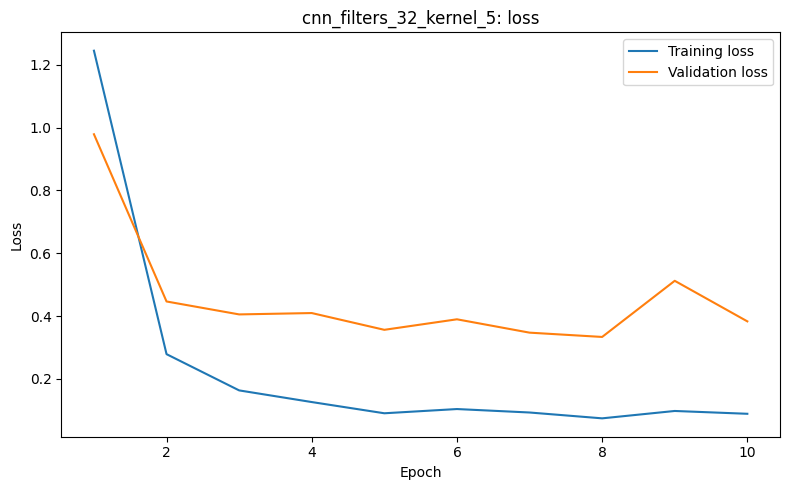

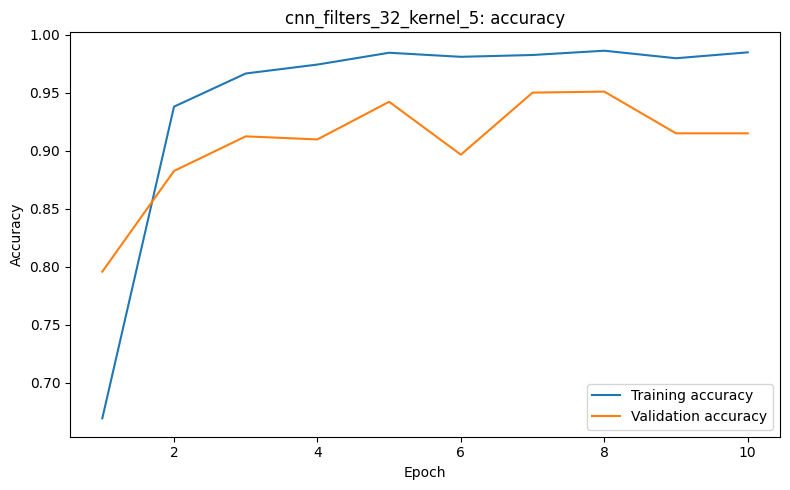

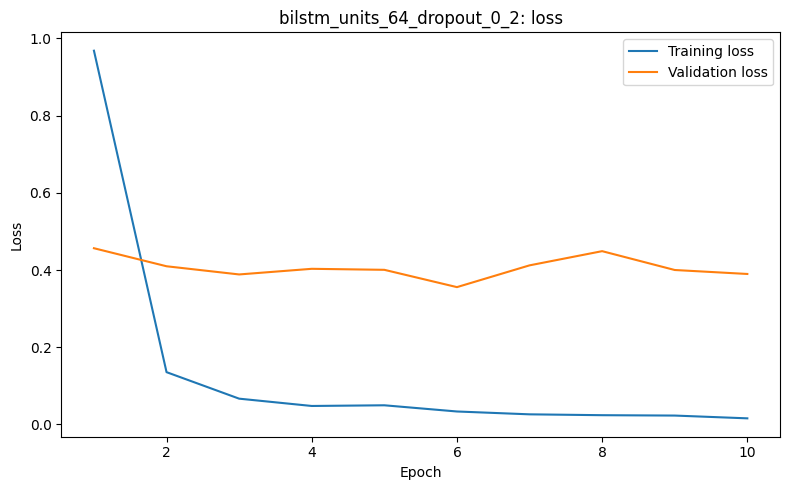

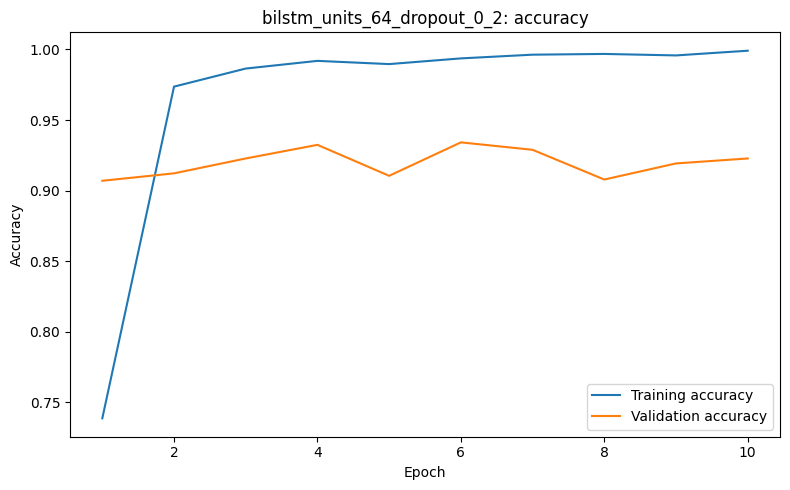

In [57]:
# TRAINING CURVES

def plot_training_history(
    history: dict,
    model_name: str,
):

    history_dataframe = pd.DataFrame(
        history
    )

    epochs = np.arange(
        1,
        len(history_dataframe) + 1,
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_dataframe["loss"],
        label="Training loss",
    )

    plt.plot(
        epochs,
        history_dataframe["val_loss"],
        label="Validation loss",
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name}: loss")
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR
        / f"{model_name}_loss.png",
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_dataframe["accuracy"],
        label="Training accuracy",
    )

    plt.plot(
        epochs,
        history_dataframe["val_accuracy"],
        label="Validation accuracy",
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name}: accuracy")
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR
        / f"{model_name}_accuracy.png",
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()


best_cnn_experiment = (
    cnn_results.iloc[0]["experiment"]
)

best_bilstm_experiment = (
    bilstm_results.iloc[0]["experiment"]
)


print(
    "Best CNN:",
    best_cnn_experiment,
)

print(
    "Best BiLSTM:",
    best_bilstm_experiment,
)


plot_training_history(
    cnn_histories[
        best_cnn_experiment
    ],
    best_cnn_experiment,
)


plot_training_history(
    bilstm_histories[
        best_bilstm_experiment
    ],
    best_bilstm_experiment,
)

In [58]:
# LOAD BEST MODELS

best_cnn_path = Path(
    cnn_results.iloc[0][
        "model_path"
    ]
)


best_bilstm_path = Path(
    bilstm_results.iloc[0][
        "model_path"
    ]
)


best_cnn_model = (
    tf.keras.models.load_model(
        best_cnn_path
    )
)


best_bilstm_model = (
    tf.keras.models.load_model(
        best_bilstm_path
    )
)


print(
    "Loaded CNN:",
    best_cnn_path,
)

print(
    "Loaded BiLSTM:",
    best_bilstm_path,
)

Loaded CNN: content/ADS2_A2_WearableHAR/models/cnn_filters_32_kernel_5.keras
Loaded BiLSTM: content/ADS2_A2_WearableHAR/models/bilstm_units_64_dropout_0_2.keras


In [ ]:
# FINAL TEST EVALUATION

def evaluate_predictions(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    model_name: str,
) -> dict:

    accuracy = accuracy_score(
        y_true,
        y_pred,
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
    )

    return {
        "model": model_name,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    }


def measure_keras_inference(
    model: tf.keras.Model,
    features: np.ndarray,
):

    # Warm-up inference.
    _ = model.predict(
        features[:64],
        batch_size=64,
        verbose=0,
    )

    start_time = time.perf_counter()

    probabilities = model.predict(
        features,
        batch_size=BATCH_SIZE,
        verbose=0,
    )

    elapsed_seconds = (
        time.perf_counter()
        - start_time
    )

    predictions = np.argmax(
        probabilities,
        axis=1,
    )

    milliseconds_per_sample = (
        elapsed_seconds
        / len(features)
    ) * 1000

    return (
        predictions,
        probabilities,
        elapsed_seconds,
        milliseconds_per_sample,
    )


def measure_xgb_inference(
    model: XGBClassifier,
    features: np.ndarray,
):

    # Warm-up inference.
    _ = model.predict_proba(
        features[:64]
    )

    start_time = time.perf_counter()

    probabilities = model.predict_proba(
        features
    )

    elapsed_seconds = (
        time.perf_counter()
        - start_time
    )

    predictions = np.argmax(
        probabilities,
        axis=1,
    )

    milliseconds_per_sample = (
        elapsed_seconds
        / len(features)
    ) * 1000

    return (
        predictions,
        probabilities,
        elapsed_seconds,
        milliseconds_per_sample,
    )


(
    xgb_test_predictions,
    xgb_test_probabilities,
    xgb_inference_seconds,
    xgb_ms_per_sample,
) = measure_xgb_inference(
    xgb_model,
    X_test_features,
)


(
    cnn_test_predictions,
    cnn_test_probabilities,
    cnn_inference_seconds,
    cnn_ms_per_sample,
) = measure_keras_inference(
    best_cnn_model,
    X_test_scaled,
)


(
    bilstm_test_predictions,
    bilstm_test_probabilities,
    bilstm_inference_seconds,
    bilstm_ms_per_sample,
) = measure_keras_inference(
    best_bilstm_model,
    X_test_scaled,
)


xgb_metrics = evaluate_predictions(
    y_test,
    xgb_test_predictions,
    "XGBoost baseline",
)


cnn_metrics = evaluate_predictions(
    y_test,
    cnn_test_predictions,
    "1D CNN",
)


bilstm_metrics = evaluate_predictions(
    y_test,
    bilstm_test_predictions,
    "Bidirectional LSTM",
)


xgb_metrics.update(
    {
        "training_seconds": (
            xgb_training_seconds
        ),
        "inference_seconds": (
            xgb_inference_seconds
        ),
        "milliseconds_per_sample": (
            xgb_ms_per_sample
        ),
        "model_size_mb": (
            XGB_MODEL_PATH.stat().st_size
            / (1024 ** 2)
        ),
    }
)


cnn_metrics.update(
    {
        "training_seconds": float(
            cnn_results.iloc[0][
                "training_seconds"
            ]
        ),
        "inference_seconds": (
            cnn_inference_seconds
        ),
        "milliseconds_per_sample": (
            cnn_ms_per_sample
        ),
        "model_size_mb": (
            best_cnn_path.stat().st_size
            / (1024 ** 2)
        ),
        "parameter_count": (
            best_cnn_model.count_params()
        ),
    }
)


bilstm_metrics.update(
    {
        "training_seconds": float(
            bilstm_results.iloc[0][
                "training_seconds"
            ]
        ),
        "inference_seconds": (
            bilstm_inference_seconds
        ),
        "milliseconds_per_sample": (
            bilstm_ms_per_sample
        ),
        "model_size_mb": (
            best_bilstm_path.stat().st_size
            / (1024 ** 2)
        ),
        "parameter_count": (
            best_bilstm_model.count_params()
        ),
    }
)


model_comparison = pd.DataFrame(
    [
        xgb_metrics,
        cnn_metrics,
        bilstm_metrics,
    ]
)


display(model_comparison)


model_comparison.to_csv(
    RESULTS_DIR
    / "model_comparison.csv",
    index=False,
)

In [ ]:
# CLASSIFICATION REPORTS

def save_classification_report(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    model_name: str,
):

    report_dictionary = (
        classification_report(
            y_true,
            y_pred,
            labels=list(
                range(
                    NUMBER_OF_CLASSES
                )
            ),
            target_names=[
                ID_TO_ACTIVITY[index]
                for index in range(
                    NUMBER_OF_CLASSES
                )
            ],
            output_dict=True,
            digits=4,
            zero_division=0,
        )
    )

    report_dataframe = (
        pd.DataFrame(
            report_dictionary
        ).transpose()
    )

    report_dataframe.to_csv(
        RESULTS_DIR
        / (
            f"{model_name}"
            f"_classification_report.csv"
        )
    )

    display(report_dataframe)

    return report_dataframe


xgb_report = save_classification_report(
    y_test,
    xgb_test_predictions,
    "xgboost",
)


cnn_report = save_classification_report(
    y_test,
    cnn_test_predictions,
    "cnn",
)


bilstm_report = save_classification_report(
    y_test,
    bilstm_test_predictions,
    "bilstm",
)

In [ ]:
# CONFUSION MATRICES

def plot_confusion_matrix(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    model_name: str,
):

    matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=list(
            range(
                NUMBER_OF_CLASSES
            )
        ),
    )

    figure, axis = plt.subplots(
        figsize=(13, 11)
    )

    display_object = (
        ConfusionMatrixDisplay(
            confusion_matrix=matrix,
            display_labels=[
                ID_TO_CODE[index]
                for index in range(
                    NUMBER_OF_CLASSES
                )
            ],
        )
    )

    display_object.plot(
        ax=axis,
        cmap="Blues",
        colorbar=True,
        values_format="d",
    )

    axis.set_title(
        f"{model_name}: confusion matrix"
    )

    figure.tight_layout()

    figure.savefig(
        FIGURE_DIR
        / (
            f"{model_name}"
            f"_confusion_matrix.png"
        ),
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

    return matrix


xgb_confusion_matrix = (
    plot_confusion_matrix(
        y_test,
        xgb_test_predictions,
        "XGBoost",
    )
)


cnn_confusion_matrix = (
    plot_confusion_matrix(
        y_test,
        cnn_test_predictions,
        "CNN",
    )
)


bilstm_confusion_matrix = (
    plot_confusion_matrix(
        y_test,
        bilstm_test_predictions,
        "BiLSTM",
    )
)

In [ ]:
# PER-CLASS METRICS

def create_per_class_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    model_name: str,
) -> pd.DataFrame:

    (
        precision,
        recall,
        f1,
        support,
    ) = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(
            range(
                NUMBER_OF_CLASSES
            )
        ),
        zero_division=0,
    )

    result = pd.DataFrame(
        {
            "model": model_name,
            "activity_id": np.arange(
                NUMBER_OF_CLASSES
            ),
            "activity_code": [
                ID_TO_CODE[index]
                for index in range(
                    NUMBER_OF_CLASSES
                )
            ],
            "activity_name": [
                ID_TO_ACTIVITY[index]
                for index in range(
                    NUMBER_OF_CLASSES
                )
            ],
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "support": support,
        }
    )

    return result


per_class_metrics = pd.concat(
    [
        create_per_class_metrics(
            y_test,
            xgb_test_predictions,
            "XGBoost baseline",
        ),
        create_per_class_metrics(
            y_test,
            cnn_test_predictions,
            "1D CNN",
        ),
        create_per_class_metrics(
            y_test,
            bilstm_test_predictions,
            "Bidirectional LSTM",
        ),
    ],
    ignore_index=True,
)


display(per_class_metrics)


per_class_metrics.to_csv(
    RESULTS_DIR
    / "per_class_metrics.csv",
    index=False,
)

In [ ]:
# PER-CLASS F1 PLOT

per_class_f1_pivot = (
    per_class_metrics.pivot(
        index="activity_code",
        columns="model",
        values="f1_score",
    )
)


per_class_f1_pivot.plot(
    kind="bar",
    figsize=(14, 6),
)


plt.xlabel("Activity code")
plt.ylabel("F1 score")
plt.title("Per-class F1 comparison")
plt.ylim(0, 1.05)
plt.legend(title="Model")
plt.tight_layout()


plt.savefig(
    FIGURE_DIR
    / "per_class_f1_comparison.png",
    dpi=200,
    bbox_inches="tight",
)


plt.show()

In [ ]:
# ===================== CELL 30: MISCLASSIFICATION TABLE =====================

def get_misclassified_samples(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    probabilities: np.ndarray,
    test_subjects: np.ndarray,
) -> pd.DataFrame:

    incorrect_indices = np.where(
        y_true != y_pred
    )[0]

    records = []

    for index in incorrect_indices:

        actual_class = int(
            y_true[index]
        )

        predicted_class = int(
            y_pred[index]
        )

        records.append(
            {
                "test_index": int(index),
                "participant": (
                    test_subjects[index]
                ),
                "actual_id": actual_class,
                "actual_code": (
                    ID_TO_CODE[
                        actual_class
                    ]
                ),
                "actual_activity": (
                    ID_TO_ACTIVITY[
                        actual_class
                    ]
                ),
                "predicted_id": (
                    predicted_class
                ),
                "predicted_code": (
                    ID_TO_CODE[
                        predicted_class
                    ]
                ),
                "predicted_activity": (
                    ID_TO_ACTIVITY[
                        predicted_class
                    ]
                ),
                "prediction_confidence": float(
                    probabilities[
                        index,
                        predicted_class,
                    ]
                ),
                "actual_class_probability": float(
                    probabilities[
                        index,
                        actual_class,
                    ]
                ),
            }
        )

    return pd.DataFrame(records)


cnn_errors = (
    get_misclassified_samples(
        y_test,
        cnn_test_predictions,
        cnn_test_probabilities,
        subjects_test,
    )
    .sort_values(
        "prediction_confidence",
        ascending=False,
    )
    .reset_index(drop=True)
)


display(cnn_errors.head(20))


cnn_errors.to_csv(
    RESULTS_DIR
    / "cnn_misclassifications.csv",
    index=False,
)

In [ ]:
# VISUALISE FIVE ERRORS

def plot_misclassified_examples(
    error_dataframe: pd.DataFrame,
    sequences: np.ndarray,
    number_of_examples: int = 5,
):

    selected = error_dataframe.head(
        number_of_examples
    )

    for row in selected.itertuples(
        index=False
    ):

        sequence = sequences[
            row.test_index
        ]

        torso_acceleration = (
            acceleration_magnitude(
                sequence,
                BODY_LOCATIONS[
                    "Torso"
                ],
            )
        )

        right_leg_acceleration = (
            acceleration_magnitude(
                sequence,
                BODY_LOCATIONS[
                    "Right leg"
                ],
            )
        )

        left_leg_acceleration = (
            acceleration_magnitude(
                sequence,
                BODY_LOCATIONS[
                    "Left leg"
                ],
            )
        )

        plt.figure(figsize=(11, 5))

        plt.plot(
            torso_acceleration,
            label="Torso acceleration",
        )

        plt.plot(
            right_leg_acceleration,
            label=(
                "Right-leg acceleration"
            ),
        )

        plt.plot(
            left_leg_acceleration,
            label=(
                "Left-leg acceleration"
            ),
        )

        plt.xlabel("Timestep")

        plt.ylabel(
            "Acceleration magnitude"
        )

        plt.title(
            f"Participant "
            f"{row.participant.upper()} | "
            f"Actual: "
            f"{row.actual_code} "
            f"{row.actual_activity} | "
            f"Predicted: "
            f"{row.predicted_code} "
            f"{row.predicted_activity} | "
            f"Confidence: "
            f"{row.prediction_confidence:.3f}"
        )

        plt.legend()
        plt.tight_layout()
        plt.show()


plot_misclassified_examples(
    error_dataframe=cnn_errors,
    sequences=X_test_scaled,
    number_of_examples=5,
)

In [ ]:
# MOST FREQUENT CONFUSION PAIRS

confusion_pairs = (
    cnn_errors
    .groupby(
        [
            "actual_code",
            "actual_activity",
            "predicted_code",
            "predicted_activity",
        ]
    )
    .size()
    .reset_index(name="count")
    .sort_values(
        "count",
        ascending=False,
    )
)


display(
    confusion_pairs.head(15)
)


confusion_pairs.to_csv(
    RESULTS_DIR
    / "cnn_confusion_pairs.csv",
    index=False,
)

In [ ]:
# INPUT-GRADIENT SALIENCY FUNCTION

def compute_input_gradient_saliency(
    model: tf.keras.Model,
    sequence: np.ndarray,
    target_class=None,
):

    input_tensor = tf.convert_to_tensor(
        sequence[np.newaxis, ...],
        dtype=tf.float32,
    )

    with tf.GradientTape() as tape:

        tape.watch(input_tensor)

        probabilities = model(
            input_tensor,
            training=False,
        )

        if target_class is None:

            target_class = int(
                tf.argmax(
                    probabilities[0]
                ).numpy()
            )

        target_probability = (
            probabilities[
                :,
                target_class,
            ]
        )

    gradients = tape.gradient(
        target_probability,
        input_tensor,
    )[0].numpy()

    absolute_gradients = np.abs(
        gradients
    )

    temporal_importance = np.mean(
        absolute_gradients,
        axis=1,
    )

    channel_importance = np.mean(
        absolute_gradients,
        axis=0,
    )

    body_importance = {}

    for (
        body_name,
        start_index,
    ) in BODY_LOCATIONS.items():

        body_importance[
            body_name
        ] = float(
            np.mean(
                channel_importance[
                    start_index:
                    start_index + 9
                ]
            )
        )

    return {
        "target_class": target_class,
        "target_probability": float(
            probabilities[
                0,
                target_class,
            ].numpy()
        ),
        "temporal_importance": (
            temporal_importance
        ),
        "channel_importance": (
            channel_importance
        ),
        "body_importance": (
            body_importance
        ),
    }

In [ ]:
# SELECT EXPLANATION SAMPLE

correct_indices = np.where(
    cnn_test_predictions == y_test
)[0]


if len(correct_indices) == 0:

    raise RuntimeError(
        "No correctly classified "
        "CNN test example found."
    )


explanation_index = int(
    correct_indices[0]
)


explanation_sequence = (
    X_test_scaled[
        explanation_index
    ]
)


explanation_label = int(
    y_test[
        explanation_index
    ]
)


saliency_result = (
    compute_input_gradient_saliency(
        model=best_cnn_model,
        sequence=explanation_sequence,
        target_class=explanation_label,
    )
)


print(
    "Participant:",
    subjects_test[
        explanation_index
    ],
)


print(
    "Activity:",
    ID_TO_ACTIVITY[
        explanation_label
    ],
)


print(
    "Target probability:",
    saliency_result[
        "target_probability"
    ],
)


print(
    "Body importance:",
    saliency_result[
        "body_importance"
    ],
)

In [ ]:
# SALIENCY VISUALISATIONS

plt.figure(figsize=(12, 5))


plt.plot(
    saliency_result[
        "temporal_importance"
    ]
)


plt.xlabel("Timestep")


plt.ylabel(
    "Mean absolute input gradient"
)


plt.title(
    "CNN temporal saliency: "
    f"{ID_TO_CODE[explanation_label]} "
    f"{ID_TO_ACTIVITY[explanation_label]}"
)


plt.tight_layout()


plt.savefig(
    FIGURE_DIR
    / "cnn_temporal_saliency.png",
    dpi=200,
    bbox_inches="tight",
)


plt.show()


body_importance_dataframe = (
    pd.DataFrame(
        saliency_result[
            "body_importance"
        ].items(),
        columns=[
            "body_location",
            "importance",
        ],
    )
    .sort_values(
        "importance",
        ascending=False,
    )
)


display(
    body_importance_dataframe
)


plt.figure(figsize=(8, 5))


plt.bar(
    body_importance_dataframe[
        "body_location"
    ],
    body_importance_dataframe[
        "importance"
    ],
)


plt.xlabel("Body location")


plt.ylabel(
    "Mean absolute input gradient"
)


plt.title(
    "CNN saliency aggregated "
    "by body location"
)


plt.xticks(rotation=30)
plt.tight_layout()


plt.savefig(
    FIGURE_DIR
    / "cnn_body_location_saliency.png",
    dpi=200,
    bbox_inches="tight",
)


plt.show()

In [ ]:
# CHANNEL IMPORTANCE
channel_importance_dataframe = (
    pd.DataFrame(
        {
            "channel": CHANNEL_NAMES,
            "importance": (
                saliency_result[
                    "channel_importance"
                ]
            ),
        }
    )
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(drop=True)
)


display(
    channel_importance_dataframe.head(15)
)


channel_importance_dataframe.to_csv(
    RESULTS_DIR
    / "cnn_channel_saliency.csv",
    index=False,
)

In [ ]:
# DEPLOYMENT COMPARISON

deployment_summary = (
    model_comparison[
        [
            "model",
            "accuracy",
            "macro_f1",
            "model_size_mb",
            "milliseconds_per_sample",
        ]
    ].copy()
)


deployment_summary[
    "estimated_samples_per_second"
] = (
    1000
    / deployment_summary[
        "milliseconds_per_sample"
    ]
)


display(deployment_summary)


deployment_summary.to_csv(
    RESULTS_DIR
    / "deployment_summary.csv",
    index=False,
)

In [ ]:
# ENVIRONMENT AND CONFIGURATION

environment = {
    "python": platform.python_version(),
    "tensorflow": tf.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": (
        importlib_metadata.version(
            "matplotlib"
        )
    ),
    "scikit_learn": (
        importlib_metadata.version(
            "scikit-learn"
        )
    ),
    "xgboost": xgb.__version__,
    "seed": SEED,
    "train_subjects": TRAIN_SUBJECTS,
    "validation_subjects": VAL_SUBJECTS,
    "test_subjects": TEST_SUBJECTS,
    "batch_size": BATCH_SIZE,
    "maximum_epochs": MAX_EPOCHS,
}


with open(
    RESULTS_DIR
    / "environment_and_configuration.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        environment,
        file,
        indent=2,
    )


display(
    pd.Series(
        environment,
        name="value",
    )
)

In [ ]:
# REQUIREMENTS FILE

requirements_lines = [
    f"tensorflow=={tf.__version__}",
    f"numpy=={np.__version__}",
    f"pandas=={pd.__version__}",
    (
        "matplotlib=="
        f"{importlib_metadata.version('matplotlib')}"
    ),
    (
        "scikit-learn=="
        f"{importlib_metadata.version('scikit-learn')}"
    ),
    f"xgboost=={xgb.__version__}",
]


requirements_path = (
    PROJECT_ROOT / "requirements.txt"
)


requirements_path.write_text(
    "\n".join(
        requirements_lines
    ) + "\n",
    encoding="utf-8",
)


print(
    requirements_path.read_text()
)

In [ ]:
# SAVE SELECTED MODEL DETAILS

best_configuration = {
    "best_cnn_experiment": (
        best_cnn_experiment
    ),
    "best_cnn_model_path": str(
        best_cnn_path
    ),
    "best_bilstm_experiment": (
        best_bilstm_experiment
    ),
    "best_bilstm_model_path": str(
        best_bilstm_path
    ),
    "xgboost_model_path": str(
        XGB_MODEL_PATH
    ),
}


with open(
    RESULTS_DIR
    / "selected_models.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        best_configuration,
        file,
        indent=2,
    )


print(
    json.dumps(
        best_configuration,
        indent=2,
    )
)